Cycle 1: response = 15.0 Hz
Cycle 2: response = 14.7 Hz
Cycle 3: response = 14.4 Hz
Cycle 4: response = 14.1 Hz
Cycle 5: response = 13.8 Hz
Cycle 6: response = 13.5 Hz
Cycle 7: response = 13.2 Hz
Cycle 8: response = 12.9 Hz
Cycle 9: response = 12.6 Hz
Cycle 10: response = 12.3 Hz


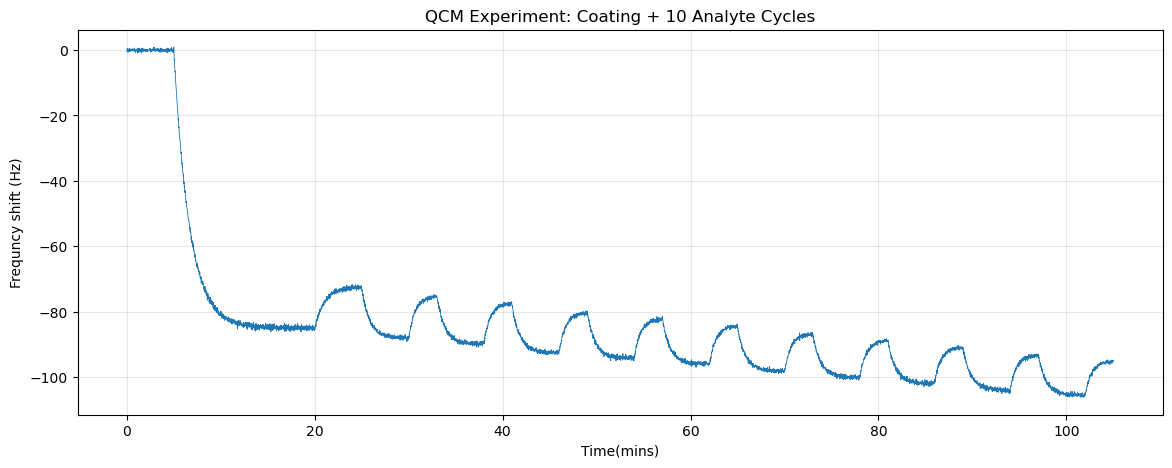

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dt = 1 # 1 sec per measurement

# Phase 1: Baseline (5 mins = 300 points)
t_baseline = np.arange(0, 300, dt)
baseline_noise = np.random.normal(0, 0.3, 300)

# Phase 2: Coating of polymer nanoparticles (15 mins = 900 points)
t_coating = np.arange(300, 1200, dt)
coating_signal = -85 * (1 - np.exp(-(t_coating - 300) / 100))
coating = coating_signal + np.random.normal(0, 0.5, 900)

# Phase 3: Rinse
t_rinse = np.arange(1200, 1500, dt)
rinse_start = coating[-1]
recovery = abs(rinse_start) * 0.15 * (1 - np.exp(-(t_rinse - 1200) / 60)) # assuming 15% of the loosely bound materials rinse off, abs because it brings the signal closer to zero
rinse = rinse_start + recovery + np.random.normal(0, 0.4, 300)

all_time = [t_baseline, t_coating, t_rinse]
all_freq = [baseline_noise, coating, rinse]

current_time = 1500
current_level = rinse[-1]

for cycle in range(10):
    degradation = 1.0 - 0.02 * cycle
    response = -15.0 * degradation

    #Analyte exposure
    t_exp = np.arange(current_time, current_time + 300, dt)
    exp_curve = response * (1 - np.exp(-(t_exp - current_time) / 50))
    exposure = current_level + exp_curve + np.random.normal(0, 0.4, 300)

    all_time.append(t_exp)
    all_freq.append(exposure)
    current_time = current_time + 300

    #Analyte rinse (3 mins = 180 points)
    t_rns = np.arange(current_time, current_time + 180 , dt)
    drop = abs(exposure[-1] - current_level)

    recovery_amount = drop * 0.85
    recovery_curve = recovery_amount * (1 - np.exp(-(t_rns - current_time) / 40))

    rns = exposure[-1] + recovery_curve + np.random.normal(0, 0.35, 180)

    all_time.append(t_rns)
    all_freq.append(rns)
    current_time = current_time + 180

    current_level = rns[-1]

    print(f"Cycle {cycle + 1}: response = {abs(response):.1f} Hz")

time_all = np.concatenate(all_time)
frequency_all = np.concatenate(all_freq)

plt.figure(figsize=(14, 5))
plt.plot(time_all/60, frequency_all, linewidth = 0.6)
plt.xlabel("Time(mins)")
plt.ylabel("Frequncy shift (Hz)")
plt.title("QCM Experiment: Coating + 10 Analyte Cycles")
plt.grid(True, alpha=0.3)
plt.show()